# 🚀 Research-Grade Pruning Framework (V6 - Final Research Edition)

### ✨ New in V6:
1.  **Local Persistence**: Models are saved in the current directory and auto-loaded to save GPU hours.
2.  **Multi-Architecture**: Seamlessly switch between **VGG16** and **ResNet18**.
3.  **Advanced Plotting**: Training/Val curves, Loss curves, and Bar charts for Params/FLOPs comparison.
4.  **Filter Insights**: Visualizes original model kernels and feature map activations.

Using device: cpu
🖼️ Visualizing Baseline Kernels...


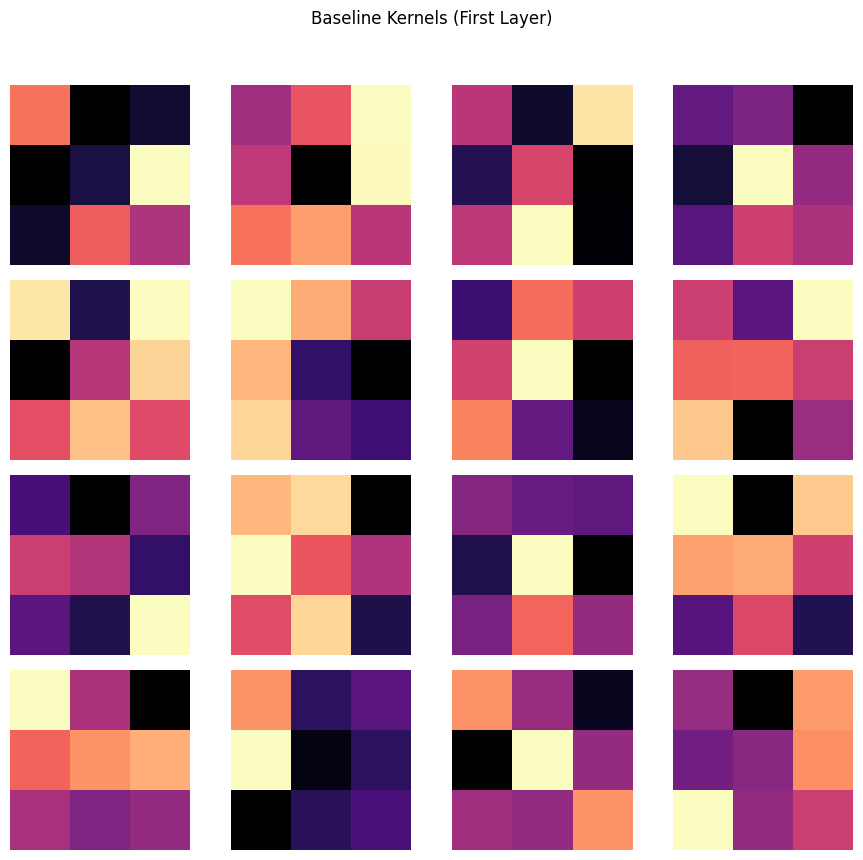

🔥 Visualizing Baseline Activations (First 3 Layers)...


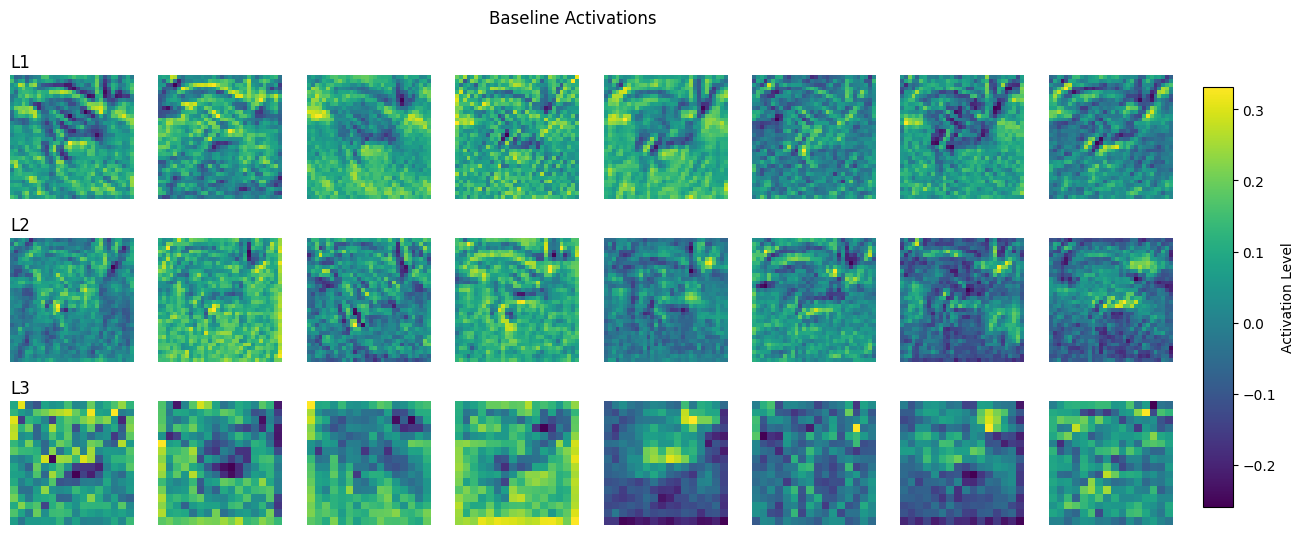

KeyboardInterrupt: 

In [1]:
!pip -q install thop seaborn tqdm matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import copy, os, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod
from typing import Dict, List, Tuple
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm
from thop import profile, clever_format
from datetime import datetime

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================================
# 1. SOTA SCORING METHODS
# =========================================
class BaseCriterion(ABC):
    @abstractmethod
    def compute_scores(self, activations: torch.Tensor, gradients: torch.Tensor = None) -> torch.Tensor: pass

class TaylorCriterion(BaseCriterion):
    def compute_scores(self, activations, gradients=None):
        if gradients is None: return activations.abs().mean(dim=(0, 2, 3))
        return (activations * gradients).abs().mean(dim=(0, 2, 3))

class APoZCriterion(BaseCriterion):
    def compute_scores(self, activations, gradients=None): return (activations == 0).float().mean(dim=(0, 2, 3))

# =========================================
# 2. HEAVY LIFTING (Generalized Engine)
# =========================================
class PruningEngine:
    def __init__(self, model):
        self.model = model
        self.dependencies = self._trace()

    def _trace(self):
        mapping = {}
        mods = list(self.model.named_modules())
        for i, (name, m) in enumerate(mods):
            if isinstance(m, nn.Conv2d):
                sibs = [mods[i+1][0]] if (i+1 < len(mods) and isinstance(mods[i+1][1], nn.BatchNorm2d)) else []
                nxt = []
                for j in range(i+1, len(mods)):
                    if isinstance(mods[j][1], (nn.Conv2d, nn.Linear)): nxt.append(mods[j][0]); break
                mapping[name] = {"siblings": sibs, "next": nxt, "out_channels": m.out_channels}
        return mapping

    def apply_masks(self, model, masks: Dict[str, torch.Tensor]):
        new_model = copy.deepcopy(model)
        for l, m in masks.items():
            idx = torch.where(m)[0]; orig_out = self.dependencies[l]["out_channels"]
            self._shrink(new_model, l, idx, 0)
            for s in self.dependencies[l]["siblings"]: self._shrink(new_model, s, idx, 0)
            for n in self.dependencies[l]["next"]: self._shrink(new_model, n, idx, 1, orig_out)
        return new_model

    def _shrink(self, model, name, idx, dim, source_channels=None):
        parts = name.split('.'); curr = model
        for p in parts[:-1]: curr = getattr(curr, p)
        m = getattr(curr, parts[-1])
        if isinstance(m, nn.Conv2d):
            if dim == 0:
                m.weight = nn.Parameter(m.weight.data[idx]); m.out_channels = len(idx)
                if m.bias is not None: m.bias = nn.Parameter(m.bias.data[idx])
            else:
                m.weight = nn.Parameter(m.weight.data[:, idx]); m.in_channels = len(idx)
        elif isinstance(m, nn.BatchNorm2d):
            m.weight = nn.Parameter(m.weight.data[idx]); m.bias = nn.Parameter(m.bias.data[idx])
            m.running_mean, m.running_var, m.num_features = m.running_mean[idx], m.running_var[idx], len(idx)
        elif isinstance(m, nn.Linear):
            if dim == 1:
                scale = m.in_features // source_channels
                new_idx = torch.cat([idx * scale + s for s in range(scale)]).sort()[0]
                m.weight = nn.Parameter(m.weight.data[:, new_idx]); m.in_features = len(new_idx)

# =========================================
# 3. ORCHESTRATOR & ANALYTICS
# =========================================
class PruningOrchestrator:
    def __init__(self, config):
        self.config = config
        self.history = {'train_acc': [], 'val_acc': [], 'val_loss': []}
        self.base_dir = os.getcwd()
        
    def get_model(self):
        if self.config['model_type'] == 'vgg16':
            m = models.vgg16_bn(num_classes=10)
            m.avgpool = nn.AdaptiveAvgPool2d((1, 1))
            m.classifier = nn.Sequential(nn.Linear(512, 512), nn.ReLU(True), nn.Linear(512, 10))
        else:
            m = models.resnet18(num_classes=10)
            m.conv1 = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
            m.maxpool = nn.Identity()
        return m.to(device)

    def train(self, model, loader, epochs, name="Training"):
        path = os.path.join(self.base_dir, f"{self.config['name']}_{self.config['model_type']}.pth")
        if name == "Baseline" and not self.config['force_retrain'] and os.path.exists(path):
            print(f"📂 Found existing model. Loading from {path}...")
            model.load_state_dict(torch.load(path, map_location=device))
            return
            
        opt = optim.Adam(model.parameters(), lr=self.config['lr'])
        crit = nn.CrossEntropyLoss()
        for e in range(epochs):
            model.train(); total_loss = 0; correct = 0; total = 0
            for x, y in tqdm(loader, desc=f"{name} E{e+1}", leave=False):
                x, y = x.to(device), y.to(device)
                opt.zero_grad(); out = model(x); loss = crit(out, y); loss.backward(); opt.step()
                total_loss += loss.item(); total += y.size(0); correct += (out.argmax(1) == y).sum().item()
            
            v_acc, v_loss = self.validate(model, loader, crit)
            self.history['train_acc'].append(100*correct/total)
            self.history['val_acc'].append(v_acc)
            self.history['val_loss'].append(v_loss)
            print(f"{name} E{e+1} | Train Acc: {100*correct/total:.2f}% | Val Acc: {v_acc:.2f}% | Val Loss: {v_loss:.4f}")
        
        if name == "Baseline":
            torch.save(model.state_dict(), path)
            print(f"💾 Model saved to: {os.path.abspath(path)}")

    def validate(self, model, loader, crit):
        model.eval(); correct = 0; total = 0; loss_sum = 0
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                out = model(x); loss_sum += crit(out, y).item()
                correct += (out.argmax(1) == y).sum().item(); total += y.size(0)
        return 100 * correct / total, loss_sum/len(loader)

    def plot_history(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
        ax1.plot(self.history['train_acc'], label='Train Acc'); ax1.plot(self.history['val_acc'], label='Val Acc')
        ax1.set_title("Accuracy Over Epochs"); ax1.legend(); ax1.grid(True)
        ax2.plot(self.history['val_loss'], color='red'); ax2.set_title("Validation Loss"); ax2.grid(True)
        plt.show()

    def plot_comparison(self, base_stats, pruned_stats):
        labels = ['Params (M)', 'FLOPs (M)']
        base = [base_stats[1]/1e6, base_stats[0]/1e6]
        pruned = [pruned_stats[1]/1e6, pruned_stats[0]/1e6]
        
        x = np.arange(len(labels)); width = 0.35
        fig, ax = plt.subplots(figsize=(10, 6))
        rects1 = ax.bar(x - width/2, base, width, label='Original', color='skyblue')
        rects2 = ax.bar(x + width/2, pruned, width, label='Pruned', color='salmon')
        
        ax.set_xticks(x); ax.set_xticklabels(labels); ax.legend(); ax.set_title("Resource Reduction Overview")
        ax.grid(axis='y', alpha=0.3)
        
        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
        autolabel(rects1); autolabel(rects2)
        plt.show()
    def run(self, model, loader):
        print("\n--- Starting Pruning Pipeline ---")
        f_base, p_base = self.get_stats(model)
        acc_base = self.history['val_acc'][-1] if self.history['val_acc'] else 0
        
        # Score collection
        engine = PruningEngine(model); acts = {}; grads = {}; crit = nn.CrossEntropyLoss()
        def f_hook(n): return lambda m, i, o: acts.update({n: o})
        def b_hook(n): return lambda m, i, o: grads.update({n: o[0]})
        hooks = [m.register_forward_hook(f_hook(n)) for n,m in model.named_modules() if isinstance(m, nn.Conv2d)]
        hooks += [m.register_full_backward_hook(b_hook(n)) for n,m in model.named_modules() if isinstance(m, nn.Conv2d)]
        x, y = next(iter(loader)); x, y = x.to(device), y.to(device)
        out = model(x); loss = crit(out, y); model.zero_grad(); loss.backward()
        for h in hooks: h.remove()
        
        scores = {n: self.config['method'].compute_scores(acts[n], grads.get(n)) for n in acts.keys()}
        masks = {l: (torch.topk(s, int(self.config['ratio'] * s.numel()), largest=False)[1]) for l,s in scores.items()}
        final_masks = {l: torch.ones(s.numel(), dtype=torch.bool).to(device) for l,s in scores.items()}
        for l, p_idx in masks.items(): final_masks[l][p_idx] = False
        
        pruned = engine.apply_masks(model, final_masks)
        acc_post = self.validate(pruned, loader, crit)[0]
        print(f"Post-Surgery Acc: {acc_post:.2f}%")
        
        self.train(pruned, loader, self.config['ft_epochs'], "Fine-Tune")
        acc_final = self.validate(pruned, loader, crit)[0]
        f_pruned, p_pruned = self.get_stats(pruned)
        
        self.plot_comparison((f_base, p_base), (f_pruned, p_pruned))
        self.print_report(p_base, p_pruned, f_base, f_pruned, acc_base, acc_post, acc_final)
        return pruned, final_masks

    def get_stats(self, model):
        m_cp = copy.deepcopy(model).cpu().eval()
        flops, params = profile(m_cp, inputs=(torch.randn(1, 3, 32, 32),), verbose=False)
        return flops, params

    def print_report(self, p_base, p_pruned, f_base, f_pruned, acc_base, acc_post, acc_final):
        print("\n" + "="*50 + "\n📊 FINAL COMPARISON REPORT\n" + "="*50)
        print(f"Parameters Reduced: {(1 - p_pruned/p_base)*100:.2f}% ({p_base/1e6:.2f}M -> {p_pruned/1e6:.2f}M)")
        print(f"FLOPs Reduced:      {(1 - f_pruned/f_base)*100:.2f}% ({f_base/1e6:.2f}M -> {f_pruned/1e6:.2f}M)")
        print(f"Accuracy Flow:      Baseline {acc_base:.2f}% -> Post-Surgery {acc_post:.2f}% -> Recovered {acc_final:.2f}%")
        print("="*50)

# =========================================
# =========================================
# 4. VISUALIZATION
# =========================================
def visualize_filters(model, title="Baseline Kernels (First Layer)"):
    conv_layer = next(m for m in model.modules() if isinstance(m, nn.Conv2d))
    weights = conv_layer.weight.data.cpu().numpy(); n = min(16, weights.shape[0])
    fig, axes = plt.subplots(int(np.ceil(n/4)), 4, figsize=(9, 9))
    for i in range(n):
        ax = axes[i//4, i%4]; f = weights[i, 0]
        im = ax.imshow((f - f.min())/(f.max()-f.min()+1e-5), cmap='magma')
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def visualize_activations(model, loader, title="Feature Map Activations", num_layers=3):
    model.eval(); acts = {}
    conv_layers = [m for m in model.modules() if isinstance(m, nn.Conv2d)][:num_layers]
    hooks = []
    
    def get_hook(name):
        def hook(m, i, o): acts[name] = o
        return hook

    for i, layer in enumerate(conv_layers):
        hooks.append(layer.register_forward_hook(get_hook(f"layer_{i}")))
    
    x, _ = next(iter(loader)); x = x[:1].to(device)
    with torch.no_grad(): _ = model(x)
    for h in hooks: h.remove()
    
    fig, axes = plt.subplots(num_layers, 8, figsize=(15, 2 * num_layers))
    for i in range(num_layers):
        layer_acts = acts[f"layer_{i}"][0].cpu().numpy()
        for j in range(8):
            ax = axes[i, j]
            if j < layer_acts.shape[0]:
                im = ax.imshow(layer_acts[j], cmap='viridis')
            ax.axis('off')
            if j == 0: ax.set_title(f"L{i+1}", loc='left')
    
    fig.subplots_adjust(right=0.9)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Activation Level')
    plt.suptitle(title); plt.show()

def visualize_all_layers_heatmaps(baseline_masks, pruned_masks):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    b_data = [np.resize(np.ones(m.shape), (128,)) for m in pruned_masks.values()]
    sns.heatmap(b_data, cmap="YlGnBu", ax=ax1, vmin=0, vmax=1, cbar_kws={'label': '1=Keep'})
    ax1.set_title("Baseline Filter Distribution (All Kept)")
    ax1.set_ylabel("Layers"); ax1.set_xlabel("Filter Index (Resized to 128)")
    
    p_data = [np.resize(m.cpu().numpy(), (128,)) for m in pruned_masks.values()]
    sns.heatmap(p_data, cmap="YlGnBu", ax=ax2, vmin=0, vmax=1, cbar_kws={'label': '1=Keep, 0=Prune'})
    ax2.set_title("Pruned Filter Distribution (Surgical View)")
    ax2.set_ylabel("Layers"); ax2.set_xlabel("Filter Index (Resized to 128)")
    
    plt.tight_layout(); plt.show()
# =========================================
# 5. EXECUTION
# =========================================
config = {
    'name': 'research_exp', 
    'model_type': 'vgg16', # 'vgg16' or 'resnet18'
    'lr': 3e-4, 'epochs': 15, 'ft_epochs': 5, 'ratio': 0.4,
    'scope': 'global', 'method': TaylorCriterion(), 'force_retrain': False
}

tf = transforms.Compose([transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize((0.49, 0.48, 0.44), (0.20, 0.19, 0.20))])
loader = DataLoader(datasets.CIFAR10('./data', train=True, download=True, transform=tf), batch_size=128, shuffle=True)

orch = PruningOrchestrator(config); model = orch.get_model()

print("🖼️ Visualizing Baseline Kernels..."); visualize_filters(model, "Baseline Kernels (First Layer)")
print("🔥 Visualizing Baseline Activations (First 3 Layers)..."); visualize_activations(model, loader, "Baseline Activations", num_layers=3)

orch.train(model, loader, config['epochs'], "Baseline"); orch.plot_history()
pruned, masks = orch.run(model, loader)

print("🖼️ Visualizing Pruned Kernels..."); visualize_filters(pruned, "Pruned Kernels (First Layer)")
print("🔥 Visualizing Pruned Activations (First 3 Layers)..."); visualize_activations(pruned, loader, "Pruned Activations", num_layers=3)

print("📊 Visualizing Filter Distribution Across All Layers...")
visualize_all_layers_heatmaps(None, masks)

print("✅ Pipeline Complete.")
